## Insurance Charges Predictor
### Production-Ready Training Notebook

**Model:** Linear Regression  
**Target:** Predict insurance charges from patient features


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib  # to SAVE the model and scaler

warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2: Load and Explore the Data

In [2]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# Basic exploration 
print('Shape:', df.shape)           # how many rows and columns?
print('\nMissing values:\n', df.isnull().sum())  # any nulls?
print('\nDuplicate rows:', df.duplicated().sum()) # any duplicates?
df.head()

Shape: (1338, 7)

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Quick stats: mean, min, max, std for all numeric columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Step 3: EDA — Visualize the Data

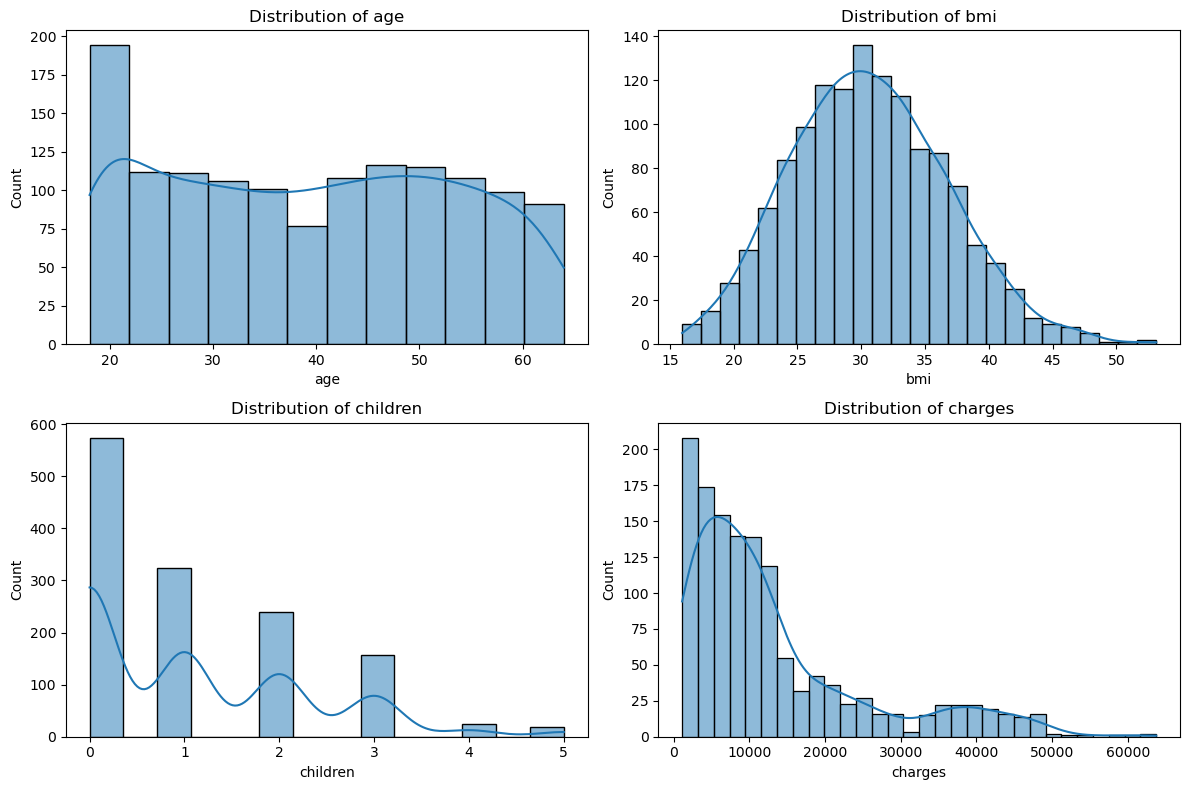

In [4]:
# Distribution of all numeric features
# KDE = smooth curve showing the probability density
numeric_columns = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 grid of plots
axes = axes.flatten()  # make it a flat list so we can loop over it

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

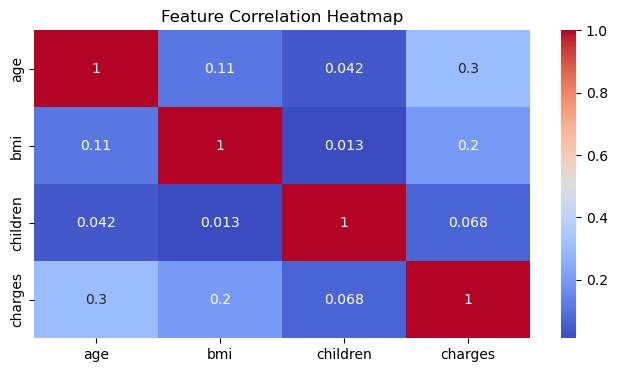

In [5]:
# Correlation heatmap — shows how features relate to each other
# Values close to 1 or -1 = strong relationship; close to 0 = weak
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Step 4: Data Cleaning & Preprocessing

In [6]:
# Always work on a copy — never modify the original DataFrame
df_cleaned = df.copy()

# Remove duplicate rows (there were a few in the original data)
df_cleaned.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df_cleaned.shape)

# Encode 'sex': male=0, female=1, and rename to be clear
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})
df_cleaned.rename(columns={'sex': 'is_female'}, inplace=True)

# Encode 'smoker': no=0, yes=1, and rename to be clear
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})
df_cleaned.rename(columns={'smoker': 'is_smoker'}, inplace=True)

# One-hot encode 'region' — converts 4 categories into 3 binary columns
# drop_first=True avoids the 'dummy variable trap' (multicollinearity)
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

# Convert all columns to int (True/False → 1/0)
df_cleaned = df_cleaned.astype(int)

print('\nColumns after encoding:', df_cleaned.columns.tolist())
df_cleaned.head()

Shape after removing duplicates: (1337, 7)

Columns after encoding: ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


## Step 5: Feature Engineering

In [7]:
# Create BMI category based on medical standards
# This captures non-linear relationships that raw BMI might miss
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['underweight', 'normal', 'overweight', 'obese']
)

# One-hot encode bmi_category — same logic as region above
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)
df_cleaned = df_cleaned.astype(int)

print('Columns after feature engineering:', df_cleaned.columns.tolist())
df_cleaned.head()

Columns after feature engineering: ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese']


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


## Step 6: Feature Selection

We use two statistical tests:
- **Pearson Correlation** — for continuous features: measures linear relationship with `charges`
- **Chi-Square Test** — for categorical features: checks if they're statistically related to `charges`

In [8]:
from scipy.stats import pearsonr

selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(
    list(correlations.items()), columns=['Feature', 'Pearson Correlation']
)
correlation_df.sort_values(by='Pearson Correlation', ascending=False, inplace=True)
print('Pearson Correlations with target (charges):')
correlation_df

Pearson Correlations with target (charges):


,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_normal,-0.104042


In [9]:
from scipy.stats import chi2_contingency

cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

alpha = 0.05  # significance threshold — p < 0.05 means the feature matters

# Bin the continuous target into 4 quartiles for chi-square compatibility
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Keep' if p_val < alpha else 'Drop'
    chi2_results[col] = {'chi2_statistic': round(chi2_stat, 2), 'p_value': round(p_val, 5), 'Decision': decision}

chi2_df = pd.DataFrame(chi2_results).T.sort_values(by='p_value')
print('Chi-Square Results:')
chi2_df

Chi-Square Results:


,chi2_statistic,p_value,Decision
is_smoker,848.22,0.0,Keep
region_southeast,16.0,0.00113,Keep
is_female,10.26,0.01649,Keep
bmi_category_obese,8.52,0.03647,Keep
region_southwest,5.09,0.16519,Drop
bmi_category_overweight,4.25,0.23556,Drop
bmi_category_normal,3.71,0.29476,Drop
region_northwest,1.13,0.76882,Drop


In [10]:
# Select the final 7 features based on statistical tests above
# charges_bin was only for the test — drop it now
df_cleaned.drop(columns=['charges_bin'], inplace=True)

FEATURE_COLS = ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region_southeast', 'bmi_category_obese']
TARGET_COL = 'charges'

final_df = df_cleaned[FEATURE_COLS + [TARGET_COL]]

print('Final feature set shape:', final_df.shape)
print('Features:', FEATURE_COLS)
final_df.head()

Final feature set shape: (1337, 8)
Features: ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region_southeast', 'bmi_category_obese']


,age,is_female,bmi,children,is_smoker,region_southeast,bmi_category_obese,charges
0,19,1,27,0,1,0,0,16884
1,18,0,33,1,0,1,1,1725
2,28,0,33,3,0,1,1,4449
3,33,0,22,0,0,0,0,21984
4,32,0,28,0,0,0,0,3866


## Step 7: Train/Test Split

⚠️ **Important:** We split the data BEFORE scaling.
If we scale first, the scaler learns from the test data — that's called **data leakage** and makes your evaluation dishonest.

In [11]:
from sklearn.model_selection import train_test_split

X = final_df[FEATURE_COLS]  # features only
y = final_df[TARGET_COL]    # target only

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 1069
Testing samples:  268


## Step 8: Scale Features (AFTER Splitting)

We only scale 3 continuous features. Binary/dummy columns (0 or 1) don't need scaling.

- `fit_transform` on train → scaler **learns** from training data only
- `transform` on test → scaler **applies** the same learned scaling (no new learning)

In [12]:
from sklearn.preprocessing import StandardScaler

# Only scale the 3 continuous numeric columns
COLS_TO_SCALE = ['age', 'bmi', 'children']

scaler = StandardScaler()

# fit_transform on TRAIN only — scaler learns mean and std from training data
X_train[COLS_TO_SCALE] = scaler.fit_transform(X_train[COLS_TO_SCALE])

# transform on TEST — apply the SAME scaling (uses training mean/std, not test)
X_test[COLS_TO_SCALE] = scaler.transform(X_test[COLS_TO_SCALE])

print('Scaling complete!')
print('Scaler mean learned from training data:', dict(zip(COLS_TO_SCALE, scaler.mean_.round(2))))
X_train.head()

Scaling complete!
Scaler mean learned from training data: {'age': np.float64(39.2), 'bmi': np.float64(30.05), 'children': np.float64(1.08)}


,age,is_female,bmi,children,is_smoker,region_southeast,bmi_category_obese
1114,-1.157680,0,-0.996513,-0.907908,0,0,0
968,-1.300619,0,-0.831737,0.766904,0,0,0
599,0.914926,1,1.145566,0.766904,0,0,1
170,1.701087,0,1.804667,-0.907908,0,1,1
275,0.557580,1,-0.666962,0.766904,0,0,0


## Step 9: Train the Model

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)  # model learns the relationship between X and y

# Make predictions on the TEST set (data model has never seen)
y_pred = model.predict(X_test)

print('Model trained successfully!')

Model trained successfully!


## Step 10: Evaluate the Model

**Metrics explained:**
- **R²** — how much variance the model explains (1.0 = perfect, 0 = no better than guessing the mean)
- **Adjusted R²** — penalizes for adding useless features; more honest than R²
- **MAE** — average absolute prediction error in dollars (easy to interpret)
- **RMSE** — similar to MAE but punishes large errors more

In [14]:
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]  # number of test samples
p = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 40)
print(f'  R² Score:       {r2:.4f}')
print(f'  Adjusted R²:    {adjusted_r2:.4f}')
print(f'  MAE:            ${mae:,.2f}')
print(f'  RMSE:           ${rmse:,.2f}')
print('=' * 40)

  R² Score:       0.8041
  Adjusted R²:    0.7988
  MAE:            $4,295.20
  RMSE:           $6,000.26


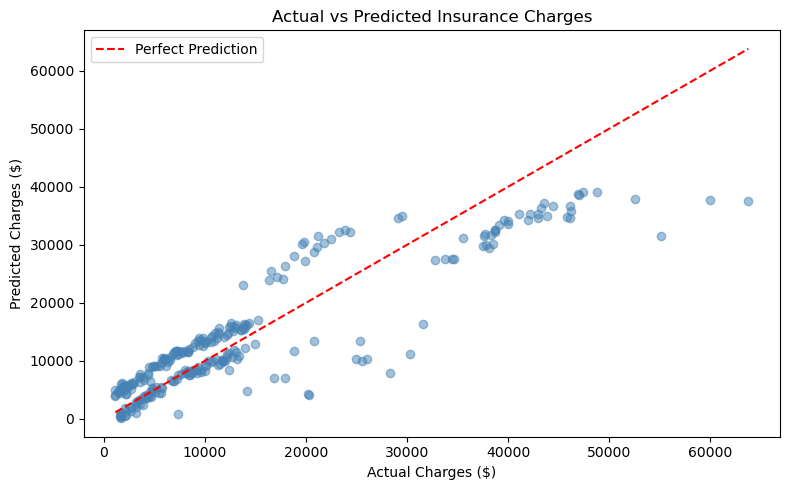

In [15]:
# Visual check: Actual vs Predicted
# A perfect model would have all dots on the diagonal line
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11: Save the Model and Scaler

This is the most important step for deployment!

- **`model.pkl`** — the trained model with its learned weights/coefficients
- **`scaler.pkl`** — the scaler that knows the training data's mean and std

Both files must be saved together. When someone sends new data for prediction, we must scale it the same way we scaled the training data.

In [16]:
# joblib is the standard way to save sklearn models
# It's better than pickle for large numpy arrays (faster, smaller files)

joblib.dump(model, 'model.pkl')
print('model.pkl saved!')

joblib.dump(scaler, 'scaler.pkl')
print('scaler.pkl saved!')

print('\nBoth files saved. Ready for deployment!')

model.pkl saved!
scaler.pkl saved!

Both files saved. Ready for deployment!


## ✅ Notebook Complete!

**What we built:**
- Cleaned and encoded the insurance dataset
- Engineered a BMI category feature
- Selected 7 features using statistical tests
- Fixed the data leakage bug (split BEFORE scaling)
- Trained a Linear Regression model
- Evaluated with R², Adjusted R², MAE, RMSE
- Saved `model.pkl` and `scaler.pkl` for deployment

**Next step → Step 3: Build the FastAPI backend**